### Notebook 1 — Basic Meadowlark SLM Control with `slmsuite`

This notebook verifies reliable Python control of the Meadowlark HDMI SLM using `slmsuite 0.4.1` before integrating the Allied Vision camera or attempting GS/WGS hologram optimization.

**Hardware/software:** Meadowlark USDM19x12 HDMI SLM (1920 × 1200 pixels, 8 µm pixel pitch, 8-bit), operated at ~759 nm. The SLM is controlled through the Meadowlark Blink HDMI SDK installed on Windows 11. A ~759 nm LUT generated for a similar SLM is used temporarily; this LUT previously gave approximately 83% diffraction efficiency.

The notebook first verifies the Python environment, SDK path, LUT path, and SLM parameters. The Meadowlark object is then initialized **only once** and kept alive throughout the experiment. Initialization produces a flat phase pattern, corresponding to `slm.phase = 0` and a display value of 255.

Simple blazed gratings are generated using `slmsuite.holography.toolbox.phase.blaze()`. Blaze vectors are specified in mrad and converted to the native `kxy` units using `convert_vector()`. For a 5 mrad horizontal blaze at 759 nm, the grating period is approximately 18.98 SLM pixels and the expected displacement in the focal plane of the 300 mm lens is ~1.50 mm. Reducing the blaze to 2.5 mrad doubles the grating period to ~37.95 pixels and moves the dominant diffraction order closer to the zeroth order (~0.75 mm). Reversing the sign of the blaze reverses the diffraction pattern, while applying the blaze along the SLM y-axis rotates the diffraction pattern by approximately 90°.

Repeated phase updates were tested without reinitializing the SDK. A 100-write stress test using `settle=False` gave a mean `set_phase()` call time of **21.27 ms**, with no progressive slowdown, kernel crash, or loss of SLM communication.

Finally, the SLM was returned to flat phase and the SDK was cleanly unloaded using `slm.close_sdk()`. The associated `HDMIDisplay` window disappeared immediately, confirming successful shutdown.

**Conclusion:** Python → `slmsuite` → Meadowlark SDK → HDMI SLM control is stable and ready for camera integration.

In [1]:
# Cell 1 — Verify Python/Jupyter environment
# NO hardware access in this cell.

import sys
import platform
from importlib.metadata import version

import numpy as np
import slmsuite

print("=== Python environment ===")
print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("Platform          :", platform.platform())

print()
print("=== Package versions ===")
print("slmsuite :", version("slmsuite"))
print("NumPy    :", version("numpy"))

try:
    print("VmbPy    :", version("VmbPy"))
except Exception as exc:
    print("VmbPy    : could not determine version:", exc)

print()
print("slmsuite location :", slmsuite.__file__)

=== Python environment ===
Python executable : c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\python.exe
Python version    : 3.12.10
Platform          : Windows-11-10.0.26200-SP0

=== Package versions ===
slmsuite : 0.4.1
NumPy    : 2.5.1
VmbPy    : 1.2.2

slmsuite location : c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\__init__.py


In [2]:
# Cell 2 — Locate Meadowlark SDK and LUT candidates
# NO SDK is loaded and NO hardware is accessed.

from pathlib import Path

MEADOWLARK_ROOT = Path(r"C:\Program Files\Meadowlark Optics")

print("Meadowlark root:")
print(MEADOWLARK_ROOT)
print("Exists:", MEADOWLARK_ROOT.exists())

print("\n=== Blink SDK candidates ===")

sdk_candidates = []

if MEADOWLARK_ROOT.exists():
    for p in MEADOWLARK_ROOT.rglob("*.dll"):
        if p.name.lower() == "blink_c_wrapper.dll":
            # slmsuite itself ignores Cal Kit copies for normal SLM control
            if "cal kit" not in str(p).lower():
                sdk_candidates.append(p)

if sdk_candidates:
    for i, p in enumerate(sdk_candidates):
        header = p.with_suffix(".h")

        print(f"\nSDK candidate {i}:")
        print("DLL    :", p)
        print("Header :", header)
        print("Header exists:", header.exists())
else:
    print("No Blink_C_wrapper.dll found.")

print("\n=== LUT candidates inside Meadowlark installation ===")

lut_candidates = []

if MEADOWLARK_ROOT.exists():
    lut_candidates = list(MEADOWLARK_ROOT.rglob("*.lut"))

if lut_candidates:
    for i, p in enumerate(lut_candidates):
        print(f"{i}: {p}")
else:
    print("No .lut files found under Meadowlark installation.")

Meadowlark root:
C:\Program Files\Meadowlark Optics
Exists: True

=== Blink SDK candidates ===

SDK candidate 0:
DLL    : C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK\Blink_C_wrapper.dll
Header : C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK\Blink_C_wrapper.h
Header exists: True

=== LUT candidates inside Meadowlark installation ===
0: C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\1920x1152_linearVoltage.lut
1: C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_10bit_linearVoltage.lut
2: C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\19x12_8bit_linearVoltage.lut


In [3]:
# Cell 3 — Define Meadowlark SDK and LUT paths
# NO hardware access in this cell.

from pathlib import Path

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\LUT from Fan\759nm_roomtemp_global"
    r"\759nm_roomtemp_global\759nm_rommtemp_global.lut"
)

SDK_DLL = SDK_PATH / "Blink_C_wrapper.dll"
SDK_HEADER = SDK_PATH / "Blink_C_wrapper.h"

print("=== Meadowlark paths ===")

print("\nSDK directory:")
print(SDK_PATH)
print("Exists:", SDK_PATH.exists())

print("\nSDK DLL:")
print(SDK_DLL)
print("Exists:", SDK_DLL.exists())

print("\nSDK header:")
print(SDK_HEADER)
print("Exists:", SDK_HEADER.exists())

print("\n759 nm LUT:")
print(LUT_PATH)
print("Exists:", LUT_PATH.exists())

print("\n=== Ready for initialization? ===")

ready = (
    SDK_PATH.exists()
    and SDK_DLL.exists()
    and SDK_HEADER.exists()
    and LUT_PATH.exists()
)

print(ready)

=== Meadowlark paths ===

SDK directory:
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK
Exists: True

SDK DLL:
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK\Blink_C_wrapper.dll
Exists: True

SDK header:
C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK\Blink_C_wrapper.h
Exists: True

759 nm LUT:
C:\Users\admin\Desktop\Projects\SLM\LUT from Fan\759nm_roomtemp_global\759nm_roomtemp_global\759nm_rommtemp_global.lut
Exists: True

=== Ready for initialization? ===
True


In [4]:
# Cell 4 — Initialize Meadowlark SLM
# THIS CELL ACCESSES THE HARDWARE.
#
# Run this ONCE per Jupyter kernel session.

from slmsuite.hardware.slms.meadowlark import Meadowlark

if "slm" in globals() and slm is not None:
    print("SLM object already exists.")
    print("NOT reconnecting to the SDK.")

else:
    print("Initializing Meadowlark SLM...")

    slm = Meadowlark(
        slm_number=1,
        sdk_path=str(SDK_PATH),
        lut_path=str(LUT_PATH),
        wav_um=0.759,
        verbose=True,
    )

    print("\n=== SLM connected ===")
    print("Name       :", slm.name)
    print("Shape      :", slm.shape)
    print("Bit depth  :", slm.bitdepth)
    print("Wavelength :", slm.wav_um, "um")
    print("Pixel pitch:", slm.pitch_um, "um")

Initializing Meadowlark SLM...
Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM connected ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Bit depth  : 8
Wavelength : 0.759 um
Pixel pitch: [8. 8.] um


In [5]:
# Cell 5 — Inspect current SLM state
# NO new hardware write in this cell.

import numpy as np

print("=== Current SLM state ===")

print("\nPhase array:")
print("Shape :", slm.phase.shape)
print("dtype :", slm.phase.dtype)
print("Min   :", np.min(slm.phase))
print("Max   :", np.max(slm.phase))
print("Mean  :", np.mean(slm.phase))

print("\nDisplay array:")
print("Shape :", slm.display.shape)
print("dtype :", slm.display.dtype)
print("Min   :", np.min(slm.display))
print("Max   :", np.max(slm.display))
print("Unique values:", np.unique(slm.display))

print("\nSource/correction information:")
print("source keys:", slm.source.keys())

print("\nDefaults:")
print("phase_correct :", slm.phase_correct)
print("settle        :", slm.settle)
print("settle_time_s :", slm.settle_time_s)

=== Current SLM state ===

Phase array:
Shape : (1200, 1920)
dtype : float64
Min   : -0.0
Max   : -0.0
Mean  : 0.0

Display array:
Shape : (1200, 1920)
dtype : uint8
Min   : 255
Max   : 255
Unique values: [255]

Source/correction information:
source keys: dict_keys([])

Defaults:
phase_correct : True
settle        : False
settle_time_s : 0.3


=== Horizontal blaze ===
Requested angle     : 5.0 mrad
Blaze vector (kxy)  : (np.float64(0.005), np.float64(0.0))
Spatial frequency x : 0.052700922266139656 cycles/pixel
Grating period x    : 18.975 pixels
Expected shift @300 mm: 1.5000125001250013 mm

=== Phase array ===
Shape : (1200, 1920)
dtype : float64
Min   : -317.7189092088966 rad
Max   : 317.7189092088966 rad

Wrapped phase range:
Min : 0.008278241511398221 rad
Max : 6.283185307179558 rad


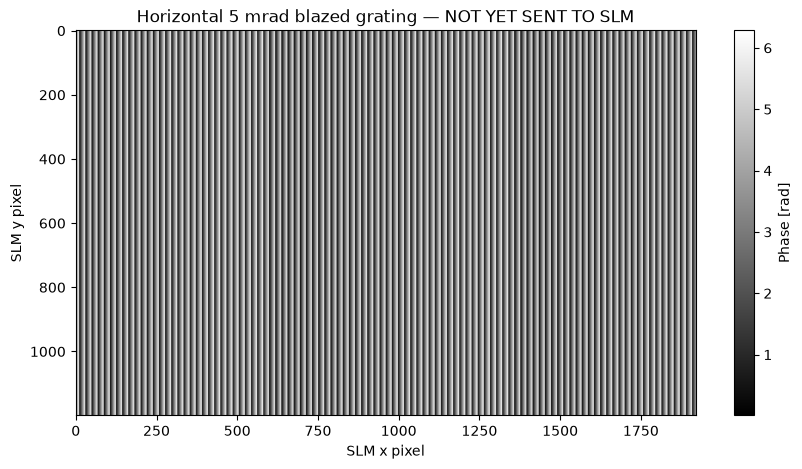

In [6]:
# Cell 6 — Generate a horizontal blazed grating IN MEMORY ONLY
# NO hardware write in this cell.

import numpy as np
import matplotlib.pyplot as plt

from slmsuite.holography.toolbox import convert_vector
from slmsuite.holography.toolbox.phase import blaze

# Desired diffraction angle.
theta_x_mrad = 5.0
theta_y_mrad = 0.0

# Convert intuitive mrad units -> slmsuite's native kx/k, ky/k units.
blaze_vector_kxy_array = convert_vector(
    (theta_x_mrad, theta_y_mrad),
    from_units="mrad",
    to_units="kxy",
    hardware=slm,
)

# convert_vector returns a column-like array; make a simple (x, y) tuple.
blaze_vector_kxy = tuple(np.ravel(blaze_vector_kxy_array))

# Generate the phase.
# IMPORTANT: this does NOT write anything to the physical SLM.
phase_blaze = blaze(
    grid=slm,
    vector=blaze_vector_kxy,
)

# Also determine the spatial frequency in cycles / SLM pixel.
freq_array = convert_vector(
    blaze_vector_kxy,
    from_units="kxy",
    to_units="freq",
    hardware=slm,
)

freq_x, freq_y = np.ravel(freq_array)

period_x_pix = np.inf if freq_x == 0 else 1.0 / abs(freq_x)

# Expected displacement in the focal plane.
f_mm = 300.0
theta_x_rad = theta_x_mrad * 1e-3
expected_shift_mm = f_mm * np.tan(theta_x_rad)

print("=== Horizontal blaze ===")
print("Requested angle     :", theta_x_mrad, "mrad")
print("Blaze vector (kxy)  :", blaze_vector_kxy)
print("Spatial frequency x :", freq_x, "cycles/pixel")
print("Grating period x    :", period_x_pix, "pixels")
print("Expected shift @300 mm:", expected_shift_mm, "mm")

print()
print("=== Phase array ===")
print("Shape :", phase_blaze.shape)
print("dtype :", phase_blaze.dtype)
print("Min   :", np.min(phase_blaze), "rad")
print("Max   :", np.max(phase_blaze), "rad")

# Wrap ONLY for visualization.
# set_phase() itself can handle the unwrapped phase later.
phase_wrapped = np.mod(phase_blaze, 2 * np.pi)

print()
print("Wrapped phase range:")
print("Min :", np.min(phase_wrapped), "rad")
print("Max :", np.max(phase_wrapped), "rad")

# Plot the wrapped phase.
plt.figure(figsize=(10, 5))
plt.imshow(
    phase_wrapped,
    cmap="gray",
    origin="upper",
    aspect="auto",
)
plt.colorbar(label="Phase [rad]")
plt.xlabel("SLM x pixel")
plt.ylabel("SLM y pixel")
plt.title("Horizontal 5 mrad blazed grating — NOT YET SENT TO SLM")
plt.show()

In [7]:
# Cell 7 — Send the horizontal blaze to the physical SLM
# THIS CELL WRITES TO THE HARDWARE.

import time
import numpy as np

print("Writing 5 mrad horizontal blaze to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_blaze,
    settle=True,
)

dt = time.perf_counter() - t0

print("Write completed.")
print(f"Total call time : {dt:.3f} s")

print()
print("=== SLM state after write ===")
print("Phase shape :", slm.phase.shape)
print("Phase min   :", np.min(slm.phase), "rad")
print("Phase max   :", np.max(slm.phase), "rad")

print()
print("Display dtype :", slm.display.dtype)
print("Display min   :", np.min(slm.display))
print("Display max   :", np.max(slm.display))
print("Number of gray levels used :", len(np.unique(slm.display)))

print()
print("SLM object still responsive:", slm.name)

Writing 5 mrad horizontal blaze to SLM...
Write completed.
Total call time : 0.322 s

=== SLM state after write ===
Phase shape : (1200, 1920)
Phase min   : 323.1668005454438 rad
Phase max   : 958.6030021191918 rad

Display dtype : uint8
Display min   : 0
Display max   : 255
Number of gray levels used : 256

SLM object still responsive: Meadowlark HDMI


In [8]:
# Cell 8 — Change horizontal blaze magnitude: 5 mrad -> 2.5 mrad
# THIS CELL WRITES TO THE HARDWARE.

import numpy as np
import time

theta_x_mrad_2 = 2.5

vector_2_kxy_array = convert_vector(
    (theta_x_mrad_2, 0.0),
    from_units="mrad",
    to_units="kxy",
    hardware=slm,
)

vector_2_kxy = tuple(np.ravel(vector_2_kxy_array))

phase_blaze_2 = blaze(
    grid=slm,
    vector=vector_2_kxy,
)

freq_2 = convert_vector(
    vector_2_kxy,
    from_units="kxy",
    to_units="freq",
    hardware=slm,
)

freq_x_2 = np.ravel(freq_2)[0]
period_x_pix_2 = 1.0 / abs(freq_x_2)

expected_shift_mm_2 = 300.0 * np.tan(theta_x_mrad_2 * 1e-3)

print("=== New blaze ===")
print("Angle          :", theta_x_mrad_2, "mrad")
print("kxy            :", vector_2_kxy)
print("Frequency      :", freq_x_2, "cycles/pixel")
print("Grating period :", period_x_pix_2, "pixels")
print("Expected shift :", expected_shift_mm_2, "mm")

print("\nWriting to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_blaze_2,
    settle=True,
)

dt = time.perf_counter() - t0

print("Write completed.")
print(f"Total call time: {dt:.3f} s")
print("SLM responsive:", slm.name)

=== New blaze ===
Angle          : 2.5 mrad
kxy            : (np.float64(0.0025), np.float64(0.0))
Frequency      : 0.026350461133069828 cycles/pixel
Grating period : 37.95 pixels
Expected shift : 0.7500015625039063 mm

Writing to SLM...
Write completed.
Total call time: 0.322 s
SLM responsive: Meadowlark HDMI


In [9]:
# Cell 9 — Reverse the horizontal blaze direction
# THIS CELL WRITES TO THE HARDWARE.

import numpy as np
import time

theta_x_mrad_neg = -2.5

vector_neg_kxy_array = convert_vector(
    (theta_x_mrad_neg, 0.0),
    from_units="mrad",
    to_units="kxy",
    hardware=slm,
)

vector_neg_kxy = tuple(np.ravel(vector_neg_kxy_array))

phase_blaze_neg = blaze(
    grid=slm,
    vector=vector_neg_kxy,
)

freq_neg = convert_vector(
    vector_neg_kxy,
    from_units="kxy",
    to_units="freq",
    hardware=slm,
)

freq_x_neg = np.ravel(freq_neg)[0]

expected_shift_mm_neg = 300.0 * np.tan(theta_x_mrad_neg * 1e-3)

print("=== Reversed horizontal blaze ===")
print("Angle          :", theta_x_mrad_neg, "mrad")
print("kxy            :", vector_neg_kxy)
print("Frequency      :", freq_x_neg, "cycles/pixel")
print("Expected shift :", expected_shift_mm_neg, "mm")

print("\nWriting to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_blaze_neg,
    settle=True,
)

dt = time.perf_counter() - t0

print("Write completed.")
print(f"Total call time: {dt:.3f} s")
print("SLM responsive:", slm.name)

=== Reversed horizontal blaze ===
Angle          : -2.5 mrad
kxy            : (np.float64(-0.0025), np.float64(0.0))
Frequency      : -0.026350461133069828 cycles/pixel
Expected shift : -0.7500015625039063 mm

Writing to SLM...
Write completed.
Total call time: 0.321 s
SLM responsive: Meadowlark HDMI


In [10]:
# Cell 10 — Apply a vertical 2.5 mrad blaze
# THIS CELL WRITES TO THE HARDWARE.

import numpy as np
import time

theta_y_mrad = 2.5

vector_y_kxy_array = convert_vector(
    (0.0, theta_y_mrad),
    from_units="mrad",
    to_units="kxy",
    hardware=slm,
)

vector_y_kxy = tuple(np.ravel(vector_y_kxy_array))

phase_blaze_y = blaze(
    grid=slm,
    vector=vector_y_kxy,
)

freq_y_array = convert_vector(
    vector_y_kxy,
    from_units="kxy",
    to_units="freq",
    hardware=slm,
)

freq_x_y, freq_y_y = np.ravel(freq_y_array)

period_y_pix = 1.0 / abs(freq_y_y)

expected_shift_mm_y = 300.0 * np.tan(theta_y_mrad * 1e-3)

print("=== Vertical blaze ===")
print("Angle y        :", theta_y_mrad, "mrad")
print("kxy            :", vector_y_kxy)
print("Frequency y    :", freq_y_y, "cycles/pixel")
print("Grating period :", period_y_pix, "pixels")
print("Expected shift :", expected_shift_mm_y, "mm")

print("\nWriting to SLM...")

t0 = time.perf_counter()

slm.set_phase(
    phase_blaze_y,
    settle=True,
)

dt = time.perf_counter() - t0

print("Write completed.")
print(f"Total call time: {dt:.3f} s")
print("SLM responsive:", slm.name)

=== Vertical blaze ===
Angle y        : 2.5 mrad
kxy            : (np.float64(0.0), np.float64(0.0025))
Frequency y    : 0.026350461133069828 cycles/pixel
Grating period : 37.95 pixels
Expected shift : 0.7500015625039063 mm

Writing to SLM...
Write completed.
Total call time: 0.319 s
SLM responsive: Meadowlark HDMI


In [11]:
# Cell 11 — Return SLM to flat phase
# THIS CELL WRITES TO THE HARDWARE.

import time
import numpy as np

print("Returning SLM to flat phase...")

t0 = time.perf_counter()

slm.set_phase(
    None,
    settle=True,
)

dt = time.perf_counter() - t0

print("Flat phase written.")
print(f"Total call time: {dt:.3f} s")

print()
print("=== SLM state ===")
print("Phase shape :", slm.phase.shape)
print("Phase min   :", np.min(slm.phase), "rad")
print("Phase max   :", np.max(slm.phase), "rad")

print()
print("Display min :", np.min(slm.display))
print("Display max :", np.max(slm.display))
print("Unique display values:", np.unique(slm.display))

print()
print("SLM responsive:", slm.name)

Returning SLM to flat phase...
Flat phase written.
Total call time: 0.320 s

=== SLM state ===
Phase shape : (1200, 1920)
Phase min   : -0.0 rad
Phase max   : -0.0 rad

Display min : 255
Display max : 255
Unique display values: [255]

SLM responsive: Meadowlark HDMI


In [12]:
# Cell 12 — Repeated SLM update stability test
# THIS CELL PERFORMS 25 HARDWARE WRITES.
#
# Important:
# - Same slm object
# - NO SDK reinitialization
# - settle=False
# - small manual dwell between writes

import time
import numpy as np

patterns = [
    ("flat",          None),
    ("x +5.0 mrad",   phase_blaze),
    ("x +2.5 mrad",   phase_blaze_2),
    ("x -2.5 mrad",   phase_blaze_neg),
    ("y +2.5 mrad",   phase_blaze_y),
]

n_cycles = 5
dwell_s = 0.20

write_times = []

print("=== Starting repeated-update stability test ===")
print("Cycles :", n_cycles)
print("Patterns per cycle :", len(patterns))
print("Total writes :", n_cycles * len(patterns))
print()

for cycle in range(n_cycles):

    print(f"--- Cycle {cycle + 1}/{n_cycles} ---")

    for name, phase in patterns:

        t0 = time.perf_counter()

        slm.set_phase(
            phase,
            settle=False,
        )

        dt = time.perf_counter() - t0
        write_times.append(dt)

        print(f"{name:15s} : {dt*1000:7.2f} ms")

        time.sleep(dwell_s)

print("\n=== Stability test completed ===")

write_times = np.asarray(write_times)

print("Number of writes :", len(write_times))
print(f"Mean write time   : {np.mean(write_times)*1000:.2f} ms")
print(f"Median write time : {np.median(write_times)*1000:.2f} ms")
print(f"Minimum           : {np.min(write_times)*1000:.2f} ms")
print(f"Maximum           : {np.max(write_times)*1000:.2f} ms")

print()
print("SLM responsive:", slm.name)

=== Starting repeated-update stability test ===
Cycles : 5
Patterns per cycle : 5
Total writes : 25

--- Cycle 1/5 ---
flat            :   19.83 ms
x +5.0 mrad     :   25.99 ms
x +2.5 mrad     :   23.98 ms
x -2.5 mrad     :   18.05 ms
y +2.5 mrad     :   28.83 ms
--- Cycle 2/5 ---
flat            :   21.57 ms
x +5.0 mrad     :   25.80 ms
x +2.5 mrad     :   22.38 ms
x -2.5 mrad     :   26.36 ms
y +2.5 mrad     :   22.02 ms
--- Cycle 3/5 ---
flat            :   19.92 ms
x +5.0 mrad     :   18.31 ms
x +2.5 mrad     :   23.23 ms
x -2.5 mrad     :   22.60 ms
y +2.5 mrad     :   20.07 ms
--- Cycle 4/5 ---
flat            :   19.34 ms
x +5.0 mrad     :   18.06 ms
x +2.5 mrad     :   22.28 ms
x -2.5 mrad     :   19.13 ms
y +2.5 mrad     :   20.23 ms
--- Cycle 5/5 ---
flat            :   18.30 ms
x +5.0 mrad     :   19.73 ms
x +2.5 mrad     :   23.07 ms
x -2.5 mrad     :   23.39 ms
y +2.5 mrad     :   21.90 ms

=== Stability test completed ===
Number of writes : 25
Mean write time   : 21.77 ms

=== Starting 100-write stability test ===
Cycles       : 20
Total writes : 100

Cycle  1/20 complete | latest write = 26.30 ms
Cycle  2/20 complete | latest write = 25.30 ms
Cycle  3/20 complete | latest write = 28.51 ms
Cycle  4/20 complete | latest write = 17.99 ms
Cycle  5/20 complete | latest write = 24.48 ms
Cycle  6/20 complete | latest write = 16.62 ms
Cycle  7/20 complete | latest write = 18.91 ms
Cycle  8/20 complete | latest write = 20.60 ms
Cycle  9/20 complete | latest write = 20.05 ms
Cycle 10/20 complete | latest write = 19.74 ms
Cycle 11/20 complete | latest write = 22.77 ms
Cycle 12/20 complete | latest write = 19.76 ms
Cycle 13/20 complete | latest write = 19.67 ms
Cycle 14/20 complete | latest write = 20.61 ms
Cycle 15/20 complete | latest write = 17.34 ms
Cycle 16/20 complete | latest write = 17.01 ms
Cycle 17/20 complete | latest write = 17.93 ms
Cycle 18/20 complete | latest write = 16.09 ms
Cycle 19/20 complete | latest write = 22.14 ms
Cycle 20/20 complete | late

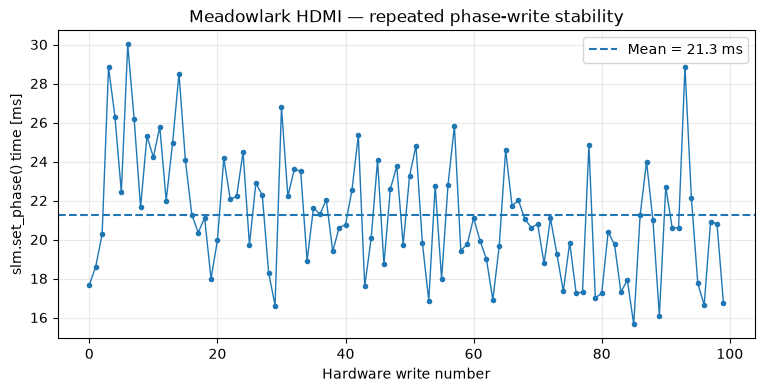

In [13]:
# Cell 13 — Longer repeated-update stability test
# THIS CELL PERFORMS 100 HARDWARE WRITES.
#
# Same SLM object. No SDK reinitialization.

import time
import numpy as np
import matplotlib.pyplot as plt

patterns = [
    ("flat",        None),
    ("x +5 mrad",   phase_blaze),
    ("x +2.5 mrad", phase_blaze_2),
    ("x -2.5 mrad", phase_blaze_neg),
    ("y +2.5 mrad", phase_blaze_y),
]

n_cycles = 20
dwell_s = 0.05

write_times_ms = []
pattern_names = []

print("=== Starting 100-write stability test ===")
print("Cycles       :", n_cycles)
print("Total writes :", n_cycles * len(patterns))
print()

for cycle in range(n_cycles):

    for name, phase in patterns:

        t0 = time.perf_counter()

        slm.set_phase(
            phase,
            settle=False,
        )

        dt_ms = (time.perf_counter() - t0) * 1000

        write_times_ms.append(dt_ms)
        pattern_names.append(name)

        time.sleep(dwell_s)

    print(
        f"Cycle {cycle + 1:2d}/{n_cycles} complete "
        f"| latest write = {write_times_ms[-1]:.2f} ms"
    )

write_times_ms = np.asarray(write_times_ms)

print("\n=== Test completed ===")
print("Number of writes :", len(write_times_ms))
print(f"Mean             : {np.mean(write_times_ms):.2f} ms")
print(f"Median           : {np.median(write_times_ms):.2f} ms")
print(f"Std. deviation   : {np.std(write_times_ms):.2f} ms")
print(f"Minimum          : {np.min(write_times_ms):.2f} ms")
print(f"Maximum          : {np.max(write_times_ms):.2f} ms")
print()
print("SLM responsive   :", slm.name)

# Plot write latency
plt.figure(figsize=(9, 4))
plt.plot(write_times_ms, marker=".", linewidth=1)

plt.axhline(
    np.mean(write_times_ms),
    linestyle="--",
    label=f"Mean = {np.mean(write_times_ms):.1f} ms",
)

plt.xlabel("Hardware write number")
plt.ylabel("slm.set_phase() time [ms]")
plt.title("Meadowlark HDMI — repeated phase-write stability")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [14]:
# Cell 14 — Final return to flat phase before shutting down
# THIS CELL WRITES TO THE HARDWARE.

import time
import numpy as np

print("Returning SLM to flat phase before shutdown...")

t0 = time.perf_counter()

slm.set_phase(
    None,
    settle=True,
)

dt = time.perf_counter() - t0

print("Flat phase written.")
print(f"Total call time: {dt:.3f} s")

print()
print("Phase min :", np.min(slm.phase))
print("Phase max :", np.max(slm.phase))

print("Display min :", np.min(slm.display))
print("Display max :", np.max(slm.display))
print("Unique display values:", np.unique(slm.display))

print()
print("SLM responsive:", slm.name)

Returning SLM to flat phase before shutdown...
Flat phase written.
Total call time: 0.320 s

Phase min : -0.0
Phase max : -0.0
Display min : 255
Display max : 255
Unique display values: [255]

SLM responsive: Meadowlark HDMI


In [15]:
slm.close()

In [16]:
# Cell 15 — Cleanly shut down the Meadowlark SDK
# Run this ONCE, at the END of the notebook.
#
# After this cell succeeds, do NOT use the old `slm` object again.

print("Closing Meadowlark SDK...")

try:
    slm.close_sdk()
    print("Meadowlark SDK closed successfully.")

    # Prevent accidental reuse of an object whose SDK has been unloaded.
    slm = None

    print("SLM object cleared.")
    print("Notebook hardware session finished cleanly.")

except Exception as exc:
    print("WARNING: SDK shutdown raised an exception:")
    print(repr(exc))

Closing Meadowlark SDK...
Meadowlark SDK closed successfully.
SLM object cleared.
Notebook hardware session finished cleanly.
